# СТАТЬИ

## Метаэвристическая методика

- формирование сводной экспертной матрицы $E_{\text{articles}}$: индивидуальная нормировка (включая диагональ), **простое среднее** по экспертам.
- метаэвристическая оптимизация $w = \arg\min_w \|A(w) - E\|_F$ при $w_k \geq 0$, $\sum_k w_k = 1$. Сравниваются GA (Genetic Algorithm, генетический алгоритм), PSO (Particle Swarm Optimization, оптимизация роем частиц), DE (Differential Evolution, дифференциальная эволюция), NRO (Nuclear Reaction Optimization, оптимизация на основе ядерной реакции): pop = 30, iter = 50, runs = 10.

## 1. Импорты и глобальные настройки

In [34]:
import json, time, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import minmax_scale
from sklearn.decomposition import LatentDirichletAllocation

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

import torch
from transformers import (AutoTokenizer, AutoModel, AutoModelForMaskedLM,
                          DataCollatorForLanguageModeling,
                          TrainingArguments, Trainer)
from torch.utils.data import Dataset

from mealpy import FloatVar
from mealpy.evolutionary_based import GA, DE
from mealpy.swarm_based import PSO
from mealpy.physics_based import NRO

import networkx as nx

# NLTK загружается здесь; если не удастся -- используем запасной список.
# Предполагается, что пользователь предварительно выполнил:
# import nltk; nltk.download('stopwords')
try:
    import nltk
    from nltk.corpus import stopwords
    russian_stopwords = set(stopwords.words('russian'))
    print(f'NLTK стоп-слова загружены: {len(russian_stopwords)} слов.')
except Exception as e:
    print(f'NLTK недоступен ({e}), использую встроенный запасной список.')
    russian_stopwords = set([
        'и','в','во','не','что','он','на','я','с','со','как','а','то',
        'все','она','так','его','но','да','ты','к','у','же','вы','за','бы','по',
        'только','ее','мне','было','вот','от','меня','еще','нет','о','из','ему',
        'теперь','когда','даже','ну','вдруг','ли','если','уже','или','ни','быть',
        'был','него','до','вас','нибудь','опять','уж','вам','ведь','там','потом',
        'себя','ничего','ей','может','они','тут','где','есть','надо','ней','для',
        'мы','тебя','их','чем','была','сам','чтоб','без','будто','чего','раз',
        'тоже','себе','под','будет','ж','тогда','кто','этот','того','потому',
        'этого','какой','совсем','ним','здесь','этом','один','почти','мой','тем',
        'чтобы','нее','сейчас','были','куда','зачем','всех','никогда','можно',
        'при','наконец','два','об','другой','хоть','после','над','больше','тот',
        'через','эти','нас','про','всего','них','какая','много','разве','три',
        'эту','моя','впрочем','хорошо','свою','этой','перед','иногда','лучше',
        'чуть','том','нельзя','такой','им','более','всегда','конечно','всю','между',
    ])

warnings.filterwarnings('ignore')
logging.getLogger('mealpy').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)

# Глобальный шрифт графиков -- Times New Roman (как в основном тексте диссертации)
mpl.rcParams['font.family']      = 'serif'
mpl.rcParams['font.serif']       = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.titlesize']   = 12
mpl.rcParams['axes.labelsize']   = 11
mpl.rcParams['xtick.labelsize']  = 10
mpl.rcParams['ytick.labelsize']  = 10
mpl.rcParams['legend.fontsize']  = 10
mpl.rcParams['figure.titlesize'] = 13

EPOCH       = 50
POP_SIZE    = 30
NUM_RUNS    = 10
EPS         = 1e-9
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

DATA_DIR = Path('.')
OUT_DIR  = Path('outputs_articles')
OUT_DIR.mkdir(exist_ok=True)

print('Среда инициализирована.')
print(f'EPOCH={EPOCH}, POP_SIZE={POP_SIZE}, NUM_RUNS={NUM_RUNS}')


NLTK стоп-слова загружены: 151 слов.
Среда инициализирована.
EPOCH=50, POP_SIZE=30, NUM_RUNS=10


## 2. Загрузка сырых данных

Ожидаются файлы в рабочей директории:
- `articles_raw (10).csv` — попарные оценки статей экспертами;
- `articles_for_claude.json` — тексты статей;
- `bert_pretrain_corpus.xlsx` — корпус для дообучения BERT (нелемматизированные тексты, колонка `text`);
- `it_math_phys_med_lemmatize.xlsx` — корпус для дообучения Word2Vec (лемматизированные тексты, колонка `text`).


In [37]:
art_raw = pd.read_csv('articles_raw (10).csv', sep=';', encoding='utf-8-sig')

with open('articles_for_claude.json', 'r', encoding='utf-8') as f:
    art_data = json.load(f)

articles = sorted(art_data['articles'], key=lambda x: x['num'])
N_ART    = len(articles)

# Айк исключён -- неполные данные (16 пар из 190)
art_raw = art_raw[art_raw['эксперт'] != 'Айк'].reset_index(drop=True)

experts_articles = sorted(art_raw['эксперт'].unique().tolist())

print(f'Статьи: {N_ART} объектов')
print(f'Эксперты: {experts_articles}')
print(f'Записей в art_raw: {len(art_raw)}')
print('Покрытие пар по экспертам:')
print(art_raw.groupby('эксперт').size().to_string())


Статьи: 20 объектов
Эксперты: ['claude', 'Артём', 'Иван', 'Эксперт']
Записей в art_raw: 760
Покрытие пар по экспертам:
эксперт
claude     190
Артём      190
Иван       190
Эксперт    190


## 3. Вспомогательные функции

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# normalize_to_01_full -- стандартная min-max нормировка ВСЕЙ матрицы в [0, 1].
# Диагональ участвует в вычислении min и max наравне с остальными
# элементами -- никаких специальных обработок диагонали нет.
# Реализация: sklearn.preprocessing.minmax_scale (библиотечная).
# ─────────────────────────────────────────────────────────────────────────────
def normalize_to_01_full(M):
    Mn = np.asarray(M, dtype=float).copy()
    # Нормируем всю матрицу как есть -- диагональ участвует наравне
    # с остальными элементами.
    Mn = minmax_scale(Mn.flatten(), feature_range=(0, 1)).reshape(M.shape)
    return Mn


# ─────────────────────────────────────────────────────────────────────────────
# simple_mean_aggregate -- простое арифметическое среднее матриц экспертов.
# numpy.nanmean корректно обрабатывает пропуски (NaN): если эксперт
# не оценил пару (i,j), его NaN не искажает среднее.
# После усреднения симметризуем матрицу и восстанавливаем диагональ.
# Реализация: numpy.nanmean (библиотечная).
# ─────────────────────────────────────────────────────────────────────────────
def simple_mean_aggregate(matrices_dict):
    stack = np.stack(list(matrices_dict.values()), axis=0)  # (n_experts, N, N)
    E = np.nanmean(stack, axis=0)                           # среднее, игнорируя NaN
    E = (E + E.T) / 2                                       # симметризация
    np.fill_diagonal(E, 1.0)
    return E


# ─────────────────────────────────────────────────────────────────────────────
# plot_heatmap -- тепловая карта матрицы.
# Реализация: seaborn.heatmap (библиотечная).
# ─────────────────────────────────────────────────────────────────────────────
def plot_heatmap(M, title, ax=None, vmin=0, vmax=1, cmap='RdYlGn',
                 xticklabels=None, yticklabels=None, annot=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(M, vmin=vmin, vmax=vmax, cmap=cmap, ax=ax,
                xticklabels=xticklabels if xticklabels is not None else False,
                yticklabels=yticklabels if yticklabels is not None else False,
                annot=annot, fmt='.2f', square=True, cbar_kws={'shrink': 0.8})
    ax.set_title(title)
    return ax


print('Вспомогательные функции определены.')


Вспомогательные функции определены.


## 4. Сводная экспертная матрица $E_{\text{articles}}$

Алгоритм:
1. Для каждого эксперта $e$ строится матрица $E^{(e)}$: $E^{(e)}_{ij} = \sqrt{q_1^{(e)} \cdot q_2^{(e)}}$.
2. Нормировка в $[0, 1]$ методом min-max **по всей матрице, включая диагональ**.
3. Сводная матрица $E_{\text{articles}}$ — **простое арифметическое среднее** нормированных матриц с обработкой пропусков (`numpy.nanmean`).


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# build_individual_matrix_articles -- строит матрицу одного эксперта.
# Для каждой оценённой пары (i,j) вычисляет геометрическое среднее
# двух вопросов. Ячейки без оценки остаются NaN -- учтётся при усреднении.
# ─────────────────────────────────────────────────────────────────────────────
def build_individual_matrix_articles(df_expert, N=N_ART):
    M = np.full((N, N), np.nan, dtype=float)
    for _, r in df_expert.iterrows():
        i = int(r['статья_А_номер']) - 1
        j = int(r['статья_Б_номер']) - 1
        # геометрическое среднее двух вопросов (формула автореферата)
        v = float(np.sqrt(float(r['вопрос_1_близость_тем']) *
                          float(r['вопрос_2_схожесть_методов'])))
        M[i, j] = v
        M[j, i] = v
    np.fill_diagonal(M, 1.0)       # статья идентична сама себе
    return M, normalize_to_01_full(M)   # нормируем по всей матрице


E_indiv_raw_A  = {}
E_indiv_norm_A = {}
for e in experts_articles:
    sub = art_raw[art_raw['эксперт'] == e]
    raw, nrm = build_individual_matrix_articles(sub)
    E_indiv_raw_A[e]  = raw
    E_indiv_norm_A[e] = nrm

# Простое среднее -- без каких-либо весов
E_articles = simple_mean_aggregate(E_indiv_norm_A)

off_mask_A = ~np.eye(N_ART, dtype=bool)

summary_A0 = pd.DataFrame({
    'эксперт': experts_articles,
    'диапазон_сырых': [
        f"[{np.nanmin(E_indiv_raw_A[e][~np.eye(N_ART, dtype=bool)]):.3f}, "
        f"{np.nanmax(E_indiv_raw_A[e][~np.eye(N_ART, dtype=bool)]):.3f}]"
        for e in experts_articles],
    'покрытие_пар': [
        int((~np.isnan(E_indiv_raw_A[e]) & ~np.eye(N_ART, dtype=bool)).sum() // 2)
        for e in experts_articles],
})
print('Сводка по экспертам (статьи):')
print(summary_A0.to_string(index=False))

print(f'\nE_articles {E_articles.shape}: '
      f'mean off={E_articles[off_mask_A].mean():.3f}, '
      f'min={E_articles[off_mask_A].min():.3f}, '
      f'max={E_articles[off_mask_A].max():.3f}, '
      f'симметрична={np.allclose(E_articles, E_articles.T)}')
summary_A0.to_csv(OUT_DIR / 'A0_experts_summary.csv', index=False, encoding='utf-8-sig')


Сводка по экспертам (статьи):
эксперт диапазон_сырых  покрытие_пар
 claude [0.100, 0.592]           190
  Артём [0.000, 0.900]           190
   Иван [0.000, 0.800]           190
Эксперт [0.000, 0.900]           190

E_articles (20, 20): mean off=0.204, min=0.000, max=0.746, симметрична=True


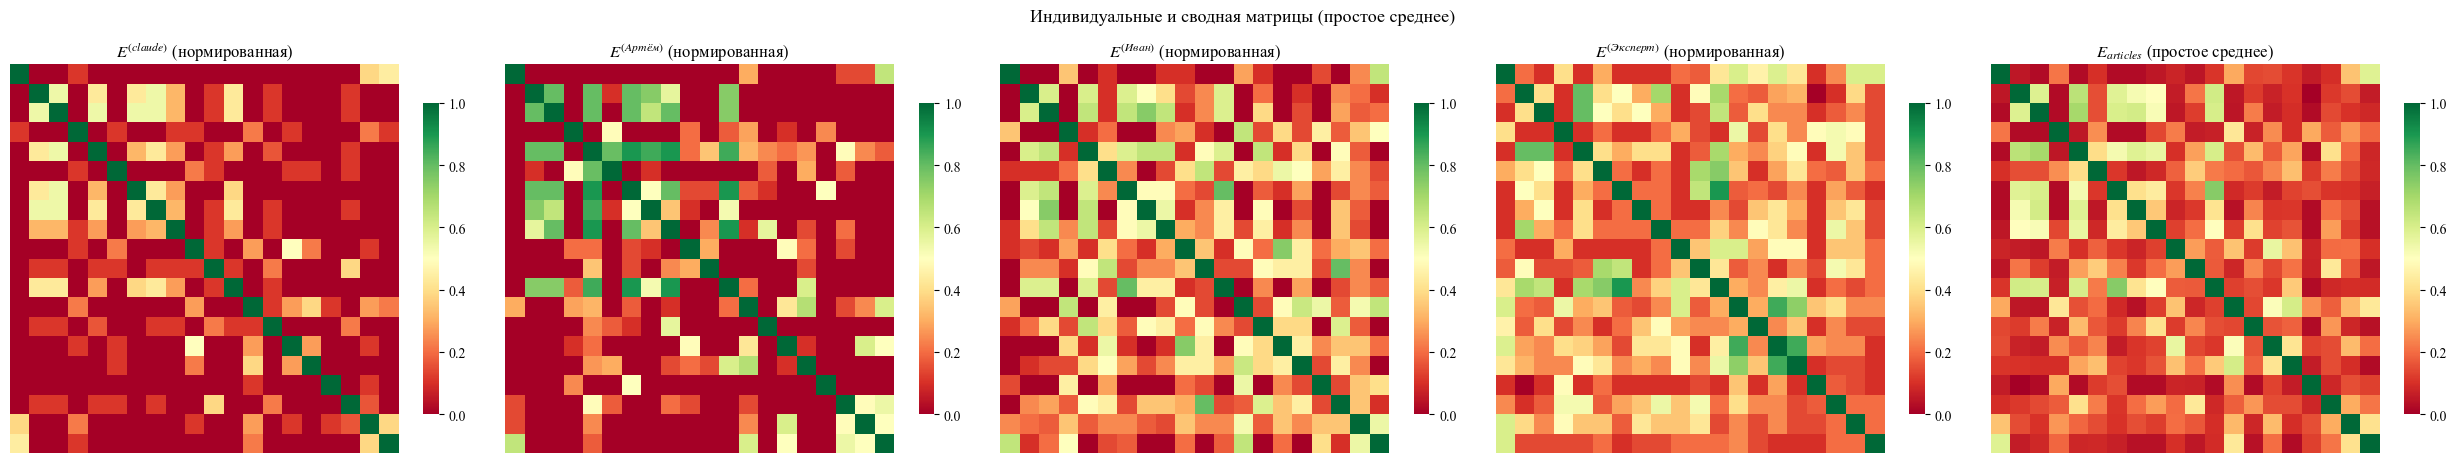

In [45]:
fig, axes = plt.subplots(1, len(experts_articles) + 1,
                         figsize=(5 * (len(experts_articles) + 1), 4.5))
for ax, e in zip(axes[:-1], experts_articles):
    plot_heatmap(E_indiv_norm_A[e], f'$E^{{({e})}}$ (нормированная)', ax=ax)
plot_heatmap(E_articles, '$E_{articles}$ (простое среднее)', ax=axes[-1])
plt.suptitle('Индивидуальные и сводная матрицы (простое среднее)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'A0_expert_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Векторизация статей

Пять методов:
1. **TF-IDF** (Term Frequency — Inverse Document Frequency, частота терма — обратная частота документа).
2. **Word2Vec** — Skip-Gram, дообучается на корпусе 4000 научных статей.
3. **BERT** (Bidirectional Encoder Representations from Transformers, двунаправленные кодирующие представления из трансформеров) — `cointegrated/rubert-tiny`, MLM-дообучение.
4. **LDA** (Latent Dirichlet Allocation, латентное размещение Дирихле) — тематическое моделирование.
5. **ICAN** (Incremental Construction of an Associative Network, инкрементальное построение ассоциативной сети) — семантический граф со-встречаемости (Demidova et al., *Algorithms*, 2023, 16(4):198).


### 5.0. Предобработка текстов

In [49]:
texts = [a['full_text'] for a in articles]

# simple_preprocess (gensim) -- библиотечная функция:
# нижний регистр, удаление пунктуации, токенизация, фильтр коротких токенов.
# Стоп-слова фильтруются списком NLTK.
tokenized_texts = [
    [t for t in simple_preprocess(text, deacc=True, min_len=3)
     if t not in russian_stopwords]
    for text in texts
]
print(f'Предобработка: {len(texts)} статей, '
      f'средняя длина после очистки: {np.mean([len(t) for t in tokenized_texts]):.0f} токенов.')


Предобработка: 20 статей, средняя длина после очистки: 1496 токенов.


### 5.1. TF-IDF

In [52]:
# TfidfVectorizer и cosine_similarity -- библиотечные реализации scikit-learn.
tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words=list(russian_stopwords))
tfidf_matrix = tfidf_vectorizer.fit_transform(
    [' '.join(t) for t in tokenized_texts]).toarray()
S_tfidf = cosine_similarity(tfidf_matrix)
print(f'TF-IDF: {tfidf_matrix.shape}, mean off-diag = {S_tfidf[off_mask_A].mean():.3f}')


TF-IDF: (20, 500), mean off-diag = 0.115


### 5.2. Word2Vec

In [55]:
PRETRAIN_DATASET_PATH = 'it_math_phys_med_lemmatize.xlsx'
W2V_SAVE_PATH         = 'w2v_model_articles.bin'

pretrain_df = pd.read_excel(PRETRAIN_DATASET_PATH, usecols=['text']).dropna(subset=['text'])
pretrain_tokens = [
    [t for t in simple_preprocess(str(row), deacc=True, min_len=3)
     if t not in russian_stopwords]
    for row in pretrain_df['text']
]
all_tokens = pretrain_tokens + tokenized_texts
print(f'Корпус для Word2Vec: {len(all_tokens)} документов '
      f'({len(pretrain_tokens)} датасет + {len(tokenized_texts)} целевых)')

if Path(W2V_SAVE_PATH).exists():
    print(f'Загружаю сохранённую модель из {W2V_SAVE_PATH}...')
    w2v_model = Word2Vec.load(W2V_SAVE_PATH)
else:
    print('Обучаю Word2Vec...')
    # Word2Vec -- библиотечная реализация gensim.
    w2v_model = Word2Vec(
        sentences=all_tokens, vector_size=100, window=7, min_count=3,
        workers=4, epochs=30, sg=1, negative=10, seed=RANDOM_SEED)
    w2v_model.save(W2V_SAVE_PATH)
print(f'Словарь: {len(w2v_model.wv)} слов.')


# ─────────────────────────────────────────────────────────────────────────────
# w2v_embedding -- усредняет векторы Word2Vec по токенам документа.
# Токены, отсутствующие в словаре модели, пропускаются.
# Если ни один токен не найден -- возвращается нулевой вектор.
# ─────────────────────────────────────────────────────────────────────────────
def w2v_embedding(tokens):
    vs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    return np.mean(vs, axis=0) if vs else np.zeros(w2v_model.vector_size)


w2v_emb = np.array([w2v_embedding(t) for t in tokenized_texts])
S_w2v   = cosine_similarity(w2v_emb)   # библиотечная (scikit-learn)
print(f'Word2Vec: {w2v_emb.shape}, mean off-diag = {S_w2v[off_mask_A].mean():.3f}')


Корпус для Word2Vec: 8587 документов (8567 датасет + 20 целевых)
Обучаю Word2Vec...
Словарь: 207391 слов.
Word2Vec: (20, 100), mean off-diag = 0.923


### 5.3. BERT (Bidirectional Encoder Representations from Transformers)

In [59]:
BERT_PRETRAIN_PATH   = 'bert_pretrain_corpus.xlsx'  # нелемматизированный корпус
BERT_MODEL_NAME      = 'cointegrated/rubert-tiny'
FINETUNE_BERT        = True
BERT_FINETUNE_EPOCHS = 3
BERT_MAX_LENGTH      = 256
BERT_BATCH_SIZE      = 8
BERT_SAVE_PATH       = './bert_articles_finetuned'


class TextDataset(Dataset):
    """Датасет для MLM-дообучения BERT."""
    def __init__(self, texts, tokenizer, max_length=BERT_MAX_LENGTH):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_length, return_tensors='pt')

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


if Path(BERT_SAVE_PATH).exists() and FINETUNE_BERT:
    print(f'Загружаю дообученный BERT из {BERT_SAVE_PATH}...')
    tokenizer  = AutoTokenizer.from_pretrained(BERT_SAVE_PATH)
    mlm_model  = AutoModelForMaskedLM.from_pretrained(BERT_SAVE_PATH)
    bert_model = mlm_model.bert
    bert_model.eval()

elif FINETUNE_BERT:
    # Для MLM-дообучения нужен живой нелемматизированный текст.
    # bert_pretrain_corpus.xlsx -- объединённый корпус из трёх источников
    # (математика, ИТ, информатика), подготовленный скриптом merge_datasets.py.
    # К нему добавляем full_text самих 20 статей эксперимента.
    pretrain_df_bert = (pd.read_excel(BERT_PRETRAIN_PATH, usecols=['text'])
                          .dropna(subset=['text']))
    all_bert_texts = pretrain_df_bert['text'].astype(str).tolist() + texts
    print(f'Корпус для BERT: {len(all_bert_texts)} текстов '
          f'({len(pretrain_df_bert)} датасет + {len(texts)} целевых)')

    tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    dataset    = TextDataset(all_bert_texts, tokenizer)
    mlm_model  = AutoModelForMaskedLM.from_pretrained(BERT_MODEL_NAME)
    collator   = DataCollatorForLanguageModeling(tokenizer=tokenizer,
                                                  mlm=True, mlm_probability=0.15)
    tr_args = TrainingArguments(
        output_dir='./bert_articles_tmp', num_train_epochs=BERT_FINETUNE_EPOCHS,
        per_device_train_batch_size=BERT_BATCH_SIZE, learning_rate=2e-5,
        weight_decay=0.01, logging_steps=50, save_strategy='no',
        use_cpu=not torch.cuda.is_available(), report_to='none', seed=RANDOM_SEED)
    Trainer(model=mlm_model, args=tr_args,
            train_dataset=dataset, data_collator=collator).train()
    mlm_model.save_pretrained(BERT_SAVE_PATH)
    tokenizer.save_pretrained(BERT_SAVE_PATH)
    bert_model = mlm_model.bert
    bert_model.eval()
    print(f'Модель сохранена в {BERT_SAVE_PATH}.')

else:
    tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
    bert_model.eval()


# ─────────────────────────────────────────────────────────────────────────────
# bert_embedding -- получает эмбеддинг текста через mean pooling:
# усреднение по токенам последнего скрытого слоя BERT.
# Это стандартный способ получить вектор фиксированной размерности
# из переменной длины последовательности.
# ─────────────────────────────────────────────────────────────────────────────
def bert_embedding(text, max_length=BERT_MAX_LENGTH):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=max_length, padding='max_length')
    with torch.no_grad():
        out = bert_model(**inputs)
    return out.last_hidden_state.mean(dim=1).numpy().flatten()


bert_emb = np.array([bert_embedding(t) for t in texts])
S_bert   = cosine_similarity(bert_emb)   # библиотечная (scikit-learn)
print(f'BERT ({"дообученный" if FINETUNE_BERT else "базовый"}): '
      f'{bert_emb.shape}, mean off-diag = {S_bert[off_mask_A].mean():.3f}')


Корпус для BERT: 2508 текстов (2488 датасет + 20 целевых)
{'loss': 4.6365, 'grad_norm': 7.349185466766357, 'learning_rate': 1.8959660297239916e-05, 'epoch': 0.1592356687898089}
{'loss': 4.4443, 'grad_norm': 6.683722972869873, 'learning_rate': 1.7898089171974523e-05, 'epoch': 0.3184713375796178}
{'loss': 4.3488, 'grad_norm': 7.561820983886719, 'learning_rate': 1.683651804670913e-05, 'epoch': 0.47770700636942676}
{'loss': 4.2624, 'grad_norm': 7.564541816711426, 'learning_rate': 1.5774946921443737e-05, 'epoch': 0.6369426751592356}
{'loss': 4.1279, 'grad_norm': 6.968329906463623, 'learning_rate': 1.4713375796178345e-05, 'epoch': 0.7961783439490446}
{'loss': 4.1226, 'grad_norm': 7.599250316619873, 'learning_rate': 1.3651804670912952e-05, 'epoch': 0.9554140127388535}
{'loss': 4.0422, 'grad_norm': 6.6395158767700195, 'learning_rate': 1.259023354564756e-05, 'epoch': 1.1146496815286624}
{'loss': 4.075, 'grad_norm': 7.309089183807373, 'learning_rate': 1.1528662420382167e-05, 'epoch': 1.273885350

### 5.4. LDA (Latent Dirichlet Allocation, латентное размещение Дирихле)

In [62]:
LDA_N_TOPICS = 6
LDA_MAX_ITER = 50

# CountVectorizer и LatentDirichletAllocation -- библиотечные (scikit-learn).
lda_count_vec = CountVectorizer(max_features=300,
                                stop_words=list(russian_stopwords), min_df=1)
X_lda_count = lda_count_vec.fit_transform([' '.join(t) for t in tokenized_texts])

lda_model  = LatentDirichletAllocation(n_components=LDA_N_TOPICS, max_iter=LDA_MAX_ITER,
                                        learning_method='batch', random_state=RANDOM_SEED)
lda_topics = lda_model.fit_transform(X_lda_count)
S_lda      = cosine_similarity(lda_topics)   # библиотечная (scikit-learn)
print(f'LDA: {LDA_N_TOPICS} тем, матрица {S_lda.shape}, '
      f'mean off-diag = {S_lda[off_mask_A].mean():.3f}')

lda_feature_names = lda_count_vec.get_feature_names_out()
print('Топ-7 слов по каждой теме:')
for i, comp in enumerate(lda_model.components_):
    top_words = [lda_feature_names[j] for j in comp.argsort()[:-8:-1]]
    print(f'  Тема {i+1}: {", ".join(top_words)}')


LDA: 6 тем, матрица (20, 20), mean off-diag = 0.306
Топ-7 слов по каждой теме:
  Тема 1: безопасности, обучения, системы, электронного, суп, the, управления
  Тема 2: техническои, поддержки, работы, эффективности, позволяет, заявок, это
  Тема 3: данных, системы, проекта, the, работы, также, технологии
  Тема 4: the, данных, информации, необходимо, вещеи, возможность, plm
  Тема 5: модели, модель, прогнозирования, временных, рядов, анализа, моделеи
  Тема 6: процессора, данных, элементов, графического, примитивов, сертификации, случае


### 5.5. ICAN (семантический граф документа)

ICAN (Incremental Construction of an Associative Network, инкрементальное построение ассоциативной сети) по статье *Demidova L. et al., Algorithms, 2023, 16(4):198*. Для каждого документа строится направленный взвешенный граф семантических связей; суммарная степень узлов используется вместо частот терминов. TF (Term Frequency, частота терма) — двойная нормированная (формула 3); IDF (Inverse Document Frequency, обратная частота документа) = $\log(|D|/df_t)$ (формула 4).

Граф строится по Algorithm 1 из статьи (окно из 11 термов, $A=0.02$, затухание 0.9, отсечение по порогу 0.4). Готовой реализации ICAN в PyPI/conda нет; реализация опирается на `networkx` (граф) и `sklearn` (косинусное сходство).


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# build_ican_graph -- строит ICAN-граф по Algorithm 1 из статьи.
#
# Для каждого токена t_i выполняются три шага:
#   1. Прямая со-встречаемость: для каждого соседа w_j в окне добавляем
#      или обновляем ребро t_i -> w_j (вероятностное накопление).
#   2. Со-встречаемость второго порядка: добавляем слабые рёбра
#      t_i -> c_k через соседей w_j -> c_k.
#   3. Затухание и отсечение: умножаем веса рёбер из t_i на decay,
#      удаляем рёбра ниже порога prune_threshold.
#
# Параметры совпадают с рекомендациями статьи:
#   window_radius=5 -> окно 2*5+1=11 токенов
#   A_scale=0.02    -> масштаб вклада второго порядка
#   decay=0.9       -> затухание
#   prune_threshold=0.4 -> порог удаления слабых рёбер
#
# networkx.DiGraph -- библиотечная структура данных для графа.
# ─────────────────────────────────────────────────────────────────────────────
def build_ican_graph(tokens, window_radius=5, A_scale=0.02,
                     decay=0.9, prune_threshold=0.4):
    G = nx.DiGraph()
    for i, t_i in enumerate(tokens):
        left   = tokens[max(0, i - window_radius): i]
        right  = tokens[i + 1: i + 1 + window_radius]
        window = list(left) + list(right)
        if t_i not in G:
            G.add_node(t_i)

        # Шаг 1: прямая со-встречаемость
        for w_j in window:
            if w_j == t_i:
                continue
            if w_j not in G:
                G.add_node(w_j)
            if G.has_edge(t_i, w_j):
                p = G[t_i][w_j]['weight']
                G[t_i][w_j]['weight'] = p + (1.0 - p) / 2.0
            else:
                G.add_edge(t_i, w_j, weight=0.5)

        # Шаг 2: со-встречаемость второго порядка
        for w_j in window:
            if w_j == t_i or not G.has_edge(t_i, w_j):
                continue
            p_ij = G[t_i][w_j]['weight']
            for c_k in list(G.successors(w_j)):
                if c_k in (t_i, w_j):
                    continue
                gamma = G[w_j][c_k]['weight']
                if G.has_edge(t_i, c_k):
                    q = G[t_i][c_k]['weight']
                    G[t_i][c_k]['weight'] = min(q + A_scale * (1.0 - q) * p_ij * gamma, 1.0)
                else:
                    G.add_edge(t_i, c_k, weight=p_ij * gamma)

        # Шаг 3: затухание и отсечение слабых рёбер
        to_remove = []
        for nb in list(G.successors(t_i)):
            nw = decay * G[t_i][nb]['weight']
            if nw < prune_threshold:
                to_remove.append((t_i, nb))
            else:
                G[t_i][nb]['weight'] = nw
        G.remove_edges_from(to_remove)

    isolated = [n for n in G.nodes() if G.degree(n) == 0]
    G.remove_nodes_from(isolated)
    return G


# ─────────────────────────────────────────────────────────────────────────────
# _node_total_degree -- суммарная степень узла: сумма весов всех
# входящих и исходящих рёбер. Аналог частоты терма (TF) в ICAN-TF-IDF.
# ─────────────────────────────────────────────────────────────────────────────
def _node_total_degree(G, node):
    return (sum(d['weight'] for _, _, d in G.out_edges(node, data=True)) +
            sum(d['weight'] for _, _, d in G.in_edges(node,  data=True)))


# ─────────────────────────────────────────────────────────────────────────────
# _build_node_document_matrix -- матрица X (N_docs x M_vocab):
# X[n, m] = суммарная степень узла m в ICAN-графе документа n.
# Аналог частотной матрицы CountVectorizer, но на основе графа.
# ─────────────────────────────────────────────────────────────────────────────
def _build_node_document_matrix(token_lists, **ican_kw):
    graphs    = [build_ican_graph(toks, **ican_kw) for toks in token_lists]
    vocab_set = set()
    for G in graphs:
        vocab_set.update(G.nodes())
    vocab = sorted(vocab_set)
    vidx  = {w: i for i, w in enumerate(vocab)}
    X = np.zeros((len(graphs), len(vocab)), dtype=float)
    for ni, G in enumerate(graphs):
        for node in G.nodes():
            X[ni, vidx[node]] = _node_total_degree(G, node)
    return X, vocab, graphs


# ─────────────────────────────────────────────────────────────────────────────
# ican_tfidf_similarity -- полный конвейер ICAN-TF-IDF:
#   токены -> граф -> степени -> двойная нормированная TF (формула 3) ->
#   IDF = log(N/df) (формула 4) -> TF-IDF ->
#   косинусные сходства (scikit-learn cosine_similarity).
#
# Защита от нулевых строк: если норма строки < 1e-12 (все IDF = 0),
# сходство с такими документами устанавливается через индексную маску,
# а не через деление на ноль.
# ─────────────────────────────────────────────────────────────────────────────
def ican_tfidf_similarity(token_lists, idf_formula='4', **ican_kw):
    X_raw, vocab, graphs = _build_node_document_matrix(token_lists, **ican_kw)

    # TF -- двойная нормированная (формула 3): tf = 0.5 + 0.5 * degree / max_degree
    X_tf    = np.zeros_like(X_raw)
    row_max = X_raw.max(axis=1, keepdims=True)
    nz      = (row_max > 0).flatten()
    X_tf[nz] = 0.5 + 0.5 * X_raw[nz] / row_max[nz]
    X_tf[X_raw == 0] = 0.0

    # IDF (формула 4)
    N   = X_raw.shape[0]
    df  = np.where((X_raw > 0).sum(axis=0) > 0, (X_raw > 0).sum(axis=0), 1)
    idf = np.log(N / df) if idf_formula == '4' else np.log(1.0 + N / df)
    idf = np.maximum(idf, 0.0)
    X_tfidf = X_tf * idf[np.newaxis, :]

    norms = np.linalg.norm(X_tfidf, axis=1)
    if np.any(norms < 1e-12):
        S = np.zeros((N, N))
        np.fill_diagonal(S, 1.0)
        nz_idx = np.where(norms >= 1e-12)[0]
        if len(nz_idx) > 1:
            S_nz = cosine_similarity(X_tfidf[nz_idx])
            for ii, gi in enumerate(nz_idx):
                for jj, gj in enumerate(nz_idx):
                    S[gi, gj] = S_nz[ii, jj]
    else:
        S = cosine_similarity(X_tfidf)   # библиотечная (scikit-learn)
    return S, X_tfidf, vocab, graphs


print('ICAN-функции определены.')


ICAN-функции определены.


In [67]:
ICAN_PARAMS = dict(window_radius=5, A_scale=0.02,
                   decay=0.9, prune_threshold=0.4, idf_formula='4')
ICAN_CACHE  = OUT_DIR / 'S_ican_articles.npy'

if ICAN_CACHE.exists():
    print(f'Загружаю кешированную матрицу ICAN из {ICAN_CACHE}...')
    S_ican      = np.load(ICAN_CACHE)
    ican_graphs = None
else:
    print(f'Строю ICAN-графы для {N_ART} статей...')
    t0 = time.time()
    S_ican, X_ican, ican_vocab, ican_graphs = ican_tfidf_similarity(
        tokenized_texts, **ICAN_PARAMS)
    elapsed = time.time() - t0
    np.save(ICAN_CACHE, S_ican)
    print(f'Готово за {elapsed:.1f} с. Словарь: {len(ican_vocab)} узлов.')
    print(f'Размеры графов (узлов): {[G.number_of_nodes() for G in ican_graphs]}')

print(f'ICAN: {S_ican.shape}, mean off-diag = {S_ican[off_mask_A].mean():.3f}')
r_ican_base, p_ican_base = pearsonr(S_ican[off_mask_A], E_articles[off_mask_A])
print(f'ICAN vs E_articles (без оптимизации): r = {r_ican_base:.4f} (p = {p_ican_base:.2e})')


Строю ICAN-графы для 20 статей...
Готово за 7.6 с. Словарь: 9047 узлов.
Размеры графов (узлов): [880, 703, 241, 1070, 888, 603, 330, 836, 886, 574, 976, 780, 794, 1005, 671, 1026, 1765, 768, 894, 873]
ICAN: (20, 20), mean off-diag = 0.039
ICAN vs E_articles (без оптимизации): r = 0.3150 (p = 3.39e-10)


Статья 1: 880 узлов, 11119 рёбер.
Топ-15 узлов по полной степени:
  модели                    deg = 143.99
  прогнозирования           deg =  92.44
  модель                    deg =  84.17
  временных                 deg =  63.93
  рядов                     deg =  63.83
  анализа                   deg =  55.93
  основе                    deg =  53.82
  является                  deg =  53.28
  моделеи                   deg =  47.60
  ряда                      deg =  46.84
  сглаживания               deg =  46.61
  наиболее                  deg =  44.85
  методы                    deg =  42.07
  также                     deg =  42.06
  являются                  deg =  39.84


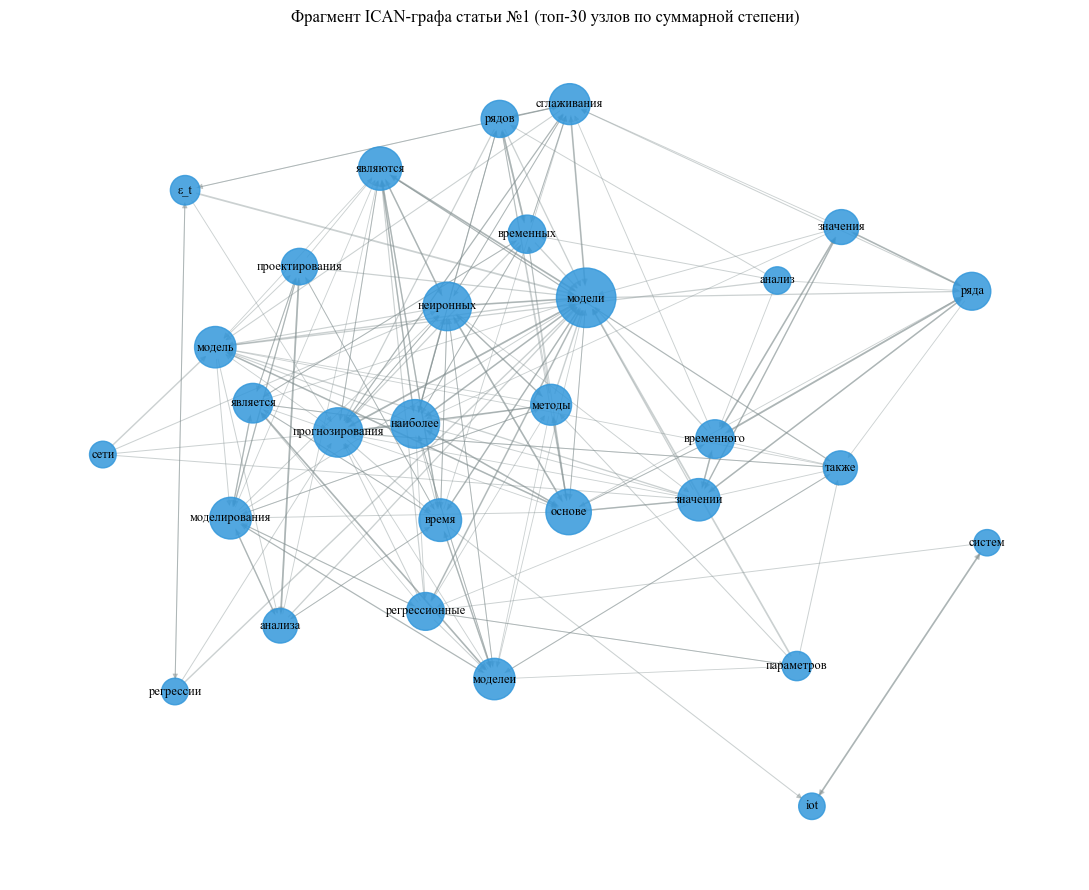

In [68]:
if ican_graphs is not None:
    G_demo = ican_graphs[0]
    degrees = sorted(((n, _node_total_degree(G_demo, n)) for n in G_demo.nodes()),
                     key=lambda x: x[1], reverse=True)
    print(f'Статья 1: {G_demo.number_of_nodes()} узлов, {G_demo.number_of_edges()} рёбер.')
    print('Топ-15 узлов по полной степени:')
    for node, deg in degrees[:15]:
        print(f'  {node:25s} deg = {deg:6.2f}')
    top_nodes = [n for n, _ in degrees[:30]]
    G_sub = G_demo.subgraph(top_nodes).copy()
    fig, ax = plt.subplots(figsize=(11, 9))
    pos        = nx.spring_layout(G_sub, seed=RANDOM_SEED, k=1.2)
    node_sizes = [200 + 80 * _node_total_degree(G_sub, n) for n in G_sub.nodes()]
    edge_widths = [d['weight'] * 1.5 for _, _, d in G_sub.edges(data=True)]
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color='#3498db', alpha=0.85, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, width=edge_widths,
                           edge_color='#7f8c8d', alpha=0.4, arrows=True, arrowsize=8, ax=ax)
    nx.draw_networkx_labels(G_sub, pos, font_size=9, font_family='Times New Roman', ax=ax)
    ax.set_title('Фрагмент ICAN-графа статьи №1 (топ-30 узлов по суммарной степени)')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'A1_ican_graph_demo.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ICAN-графы не загружены (кеш). '
          'Удалите outputs_articles/S_ican_articles.npy и перезапустите.')


## 6. Нормировка матриц сходства и корреляция с $E_{\text{articles}}$


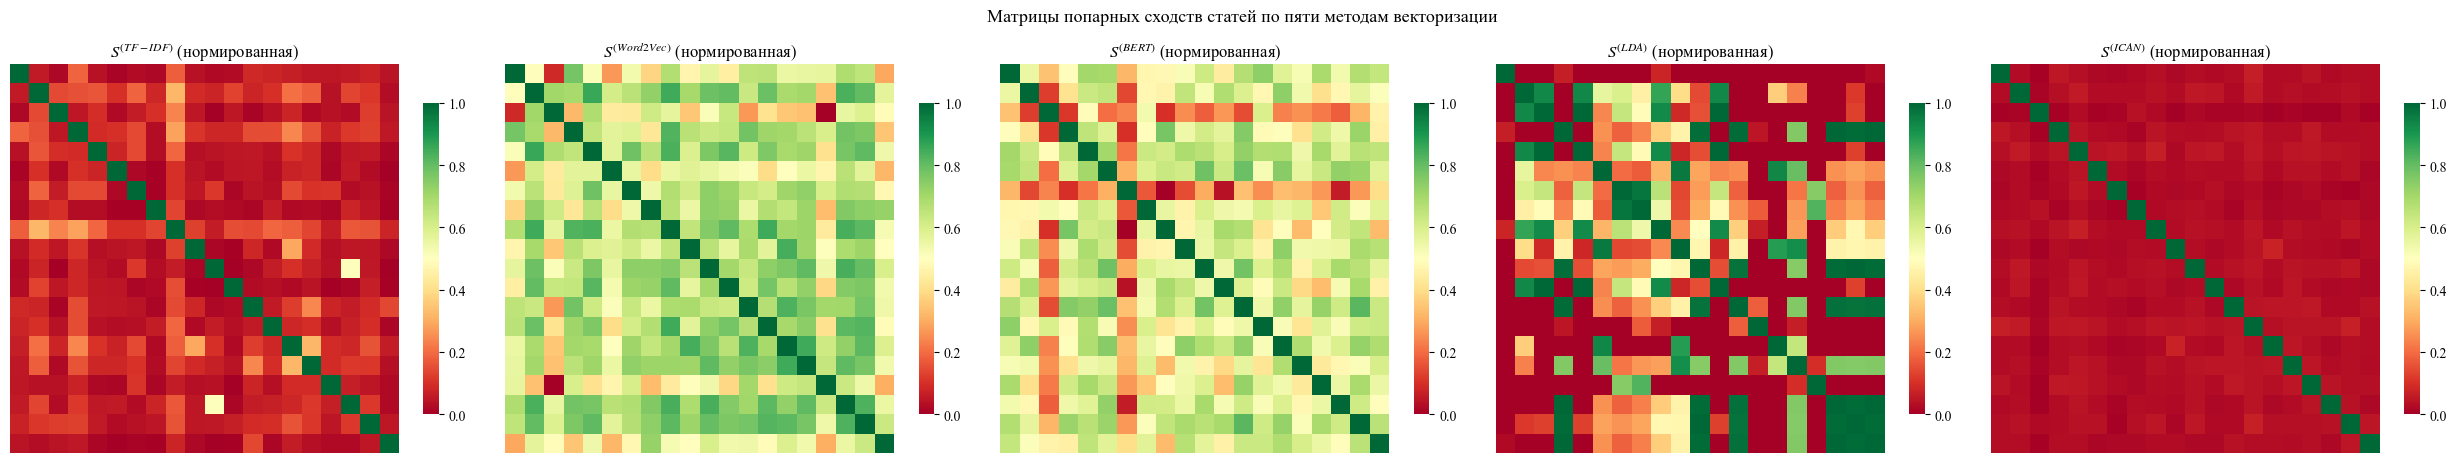

Корреляция одиночных метрик с E_articles (без оптимизации):
  TF-IDF    : r = +0.3727  (p = 5.74e-14) ***
  Word2Vec  : r = +0.3936  (p = 1.57e-15) ***
  BERT      : r = +0.0125  (p = 8.08e-01)   
  LDA       : r = +0.5239  (p = 3.55e-28) ***
  ICAN      : r = +0.3150  (p = 3.39e-10) ***


In [70]:
# Нормируем каждую матрицу по всей матрице, включая диагональ
# (тот же принцип, что и для экспертных матриц в этапе 0).
S_tfidf_n = normalize_to_01_full(S_tfidf)
S_w2v_n   = normalize_to_01_full(S_w2v)
S_bert_n  = normalize_to_01_full(S_bert)
S_lda_n   = normalize_to_01_full(S_lda)
S_ican_n  = normalize_to_01_full(S_ican)

fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for ax, M, name in zip(axes,
                        [S_tfidf_n, S_w2v_n, S_bert_n, S_lda_n, S_ican_n],
                        ['TF-IDF', 'Word2Vec', 'BERT', 'LDA', 'ICAN']):
    plot_heatmap(M, f'$S^{{({name})}}$ (нормированная)', ax=ax)
plt.suptitle('Матрицы попарных сходств статей по пяти методам векторизации', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'A1_similarity_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Корреляция одиночных метрик с E_articles (без оптимизации):')
for name, S in zip(['TF-IDF', 'Word2Vec', 'BERT', 'LDA', 'ICAN'],
                   [S_tfidf_n, S_w2v_n, S_bert_n, S_lda_n, S_ican_n]):
    r, p = pearsonr(S[off_mask_A], E_articles[off_mask_A])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '  '))
    print(f'  {name:10s}: r = {r:+.4f}  (p = {p:.2e}) {sig}')


## 7. Метаэвристическая оптимизация весов метрик

Минимизируется $F(w) = \|A(w) - E_{\text{articles}}\|_F$ по всей матрице, где
$$A(w) = \sum_{k=1}^{5} w_k S^{(k)}, \quad k \in \{\text{TF-IDF, Word2Vec, BERT, LDA, ICAN}\}, \quad w_k \geq 0, \quad \sum_k w_k = 1.$$


In [72]:
S_stack_articles      = [S_tfidf_n, S_w2v_n, S_bert_n, S_lda_n, S_ican_n]
metric_names_articles = ['TF-IDF', 'Word2Vec', 'BERT', 'LDA', 'ICAN']
K_articles = len(S_stack_articles)


# ─────────────────────────────────────────────────────────────────────────────
# A_w_articles -- взвешенная комбинация матриц сходства.
# Отрицательные значения обнуляются (mealpy работает в непрерывном
# пространстве, ограничение w >= 0 мягкое), затем нормируем на единицу
# (проекция на стандартный симплекс).
# ─────────────────────────────────────────────────────────────────────────────
def A_w_articles(w):
    w = np.maximum(w, 0)
    s = w.sum()
    w = w / s if s > 0 else np.ones(K_articles) / K_articles
    return sum(wk * Sk for wk, Sk in zip(w, S_stack_articles))


# ─────────────────────────────────────────────────────────────────────────────
# objective_articles -- целевая функция: норма Фробениуса разности
# комбинированной и экспертной матриц.
# np.linalg.norm без параметра вычисляет норму Фробениуса для матриц.
# Включает всю матрицу (в т.ч. диагональ) -- согласованно с нормировкой.
# ─────────────────────────────────────────────────────────────────────────────
def objective_articles(sol):
    A = A_w_articles(sol)
    return float(np.linalg.norm(A - E_articles))


bounds_articles  = [FloatVar(lb=0.0, ub=1.0, name=f'w_{n}')
                    for n in metric_names_articles]
problem_articles = {'obj_func': objective_articles,
                    'bounds':   bounds_articles,
                    'minmax':   'min'}

algorithms_config = {
    'GA':  {'class': GA.BaseGA,
            'params': dict(epoch=EPOCH, pop_size=POP_SIZE, pc=0.9, pm=0.1,
                           selection='tournament', k_way=0.2,
                           crossover='uniform', mutation='flip'),
            'name': 'Генетический алгоритм'},
    'PSO': {'class': PSO.OriginalPSO,
            'params': dict(epoch=EPOCH, pop_size=POP_SIZE,
                           c1=2.05, c2=2.05, w_min=0.4, w_max=0.9),
            'name': 'Оптимизация роем частиц'},
    'DE':  {'class': DE.OriginalDE,
            'params': dict(epoch=EPOCH, pop_size=POP_SIZE, wf=0.8, cr=0.9, strategy=0),
            'name': 'Дифференциальная эволюция'},
    'NRO': {'class': NRO.OriginalNRO,
            'params': dict(epoch=EPOCH, pop_size=POP_SIZE),
            'name': 'Оптимизация ядерной реакции'},
}
print('Конфигурация алгоритмов задана.')


Конфигурация алгоритмов задана.


In [119]:
import io, os, contextlib

# ─────────────────────────────────────────────────────────────────────────────
# run_metaheuristic -- запуск всех алгоритмов с NUM_RUNS повторами.
# Каждый запуск -- независимая инициализация популяции.
# Возвращает словарь с историей сходимости и весами каждого запуска.
#
# mealpy пишет лог напрямую в файловый дескриптор, минуя Python-обёртки
# sys.stdout/sys.stderr, поэтому подавляем вывод через os.devnull.
# ─────────────────────────────────────────────────────────────────────────────
def run_metaheuristic(problem_dict, alg_config, num_runs=NUM_RUNS):
    results = {}
    for algo_name, cfg in alg_config.items():
        runs = []
        for r in range(num_runs):
            opt = cfg['class'](**cfg['params'])
            t0  = time.time()
            with open(os.devnull, 'w') as devnull, \
                 contextlib.redirect_stdout(devnull), \
                 contextlib.redirect_stderr(devnull):
                agent = opt.solve(problem_dict, mode='single')
            dt  = time.time() - t0
            sol = np.maximum(agent.solution, 0)
            sol = sol / sol.sum() if sol.sum() > 0 else np.ones_like(sol) / len(sol)
            runs.append({'run_id': r + 1, 'weights': sol,
                         'distance': float(agent.target.fitness),
                         'time': dt,
                         'convergence': list(opt.history.list_global_best_fit)})
        dists = [x['distance'] for x in runs]
        times = [x['time']     for x in runs]
        cv    = np.std(dists) / np.mean(dists) * 100 if np.mean(dists) > 0 else 0.0
        print(f'  {algo_name} ({cfg["name"]}): best={min(dists):.4f}, '
              f'mean={np.mean(dists):.4f}, CV={cv:.2f}%, time={np.mean(times):.2f}s')
        results[algo_name] = {'config': cfg, 'runs': runs}
    return results


# ─────────────────────────────────────────────────────────────────────────────
# make_summary_table -- сводная таблица по всем алгоритмам:
# лучшее и среднее расстояние, стандартное отклонение, CV, среднее время.
# ─────────────────────────────────────────────────────────────────────────────
def make_summary_table(results, label):
    rows = []
    for name, r in results.items():
        d  = [x['distance'] for x in r['runs']]
        t  = [x['time']     for x in r['runs']]
        cv = np.std(d) / np.mean(d) * 100 if np.mean(d) > 0 else 0.0
        rows.append({'Алгоритм': name,
                     'Время_с_ср': np.mean(t), 'Время_с_ст.откл': np.std(t),
                     'Расстояние_лучшее': np.min(d), 'Расстояние_среднее': np.mean(d),
                     'Расстояние_ст.откл': np.std(d), 'CV_%': cv})
    df = pd.DataFrame(rows).sort_values('Расстояние_лучшее').reset_index(drop=True)
    df.to_csv(OUT_DIR / f'{label}_algorithms_comparison.csv', index=False, encoding='utf-8-sig')
    return df


print('Функции run_metaheuristic и make_summary_table определены.')

Функции run_metaheuristic и make_summary_table определены.


In [125]:
print('Запускаю метаэвристику для СТАТЕЙ...')
print(f'(EPOCH={EPOCH}, POP_SIZE={POP_SIZE}, NUM_RUNS={NUM_RUNS})\n')
results_articles = run_metaheuristic(problem_articles, algorithms_config)

summary_articles = make_summary_table(results_articles, 'A_articles')
print('\nСводная таблица алгоритмов (статьи):')
print(summary_articles.to_string(index=False))


2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: Solving single objective optimization problem.
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 2.693484854112881, Global best: 2.686968736671949, Runtime: 0.00748 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 2.6723366736357503, Global best: 2.6723366736357503, Runtime: 0.01025 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 2.6894677595325582, Global best: 2.6723366736357503, Runtime: 0.00689 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 2.688047398779148, Global best: 2.6723366736357503, Runtime: 0.00730 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 2.6986125384468465, Global best: 2.672336673635

Запускаю метаэвристику для СТАТЕЙ...
(EPOCH=50, POP_SIZE=30, NUM_RUNS=10)



2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 19, Current best: 2.6694544156202, Global best: 2.6694544156202, Runtime: 0.01427 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 20, Current best: 2.6660908877975236, Global best: 2.6660908877975236, Runtime: 0.00692 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 21, Current best: 2.667636538731915, Global best: 2.6660908877975236, Runtime: 0.00894 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 22, Current best: 2.667636538731915, Global best: 2.6660908877975236, Runtime: 0.00823 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 23, Current best: 2.667636538731915, Global best: 2.6660908877975236, Runtime: 0.00650 seconds
2026/05/08 01:06:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Ep

  GA (Генетический алгоритм): best=2.6631, mean=2.6645, CV=0.05%, time=0.39s


2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 44, Current best: 2.6624284222368098, Global best: 2.6624284222368098, Runtime: 0.00260 seconds
2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 45, Current best: 2.662419790384735, Global best: 2.662419790384735, Runtime: 0.00247 seconds
2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 46, Current best: 2.662419790384735, Global best: 2.662419790384735, Runtime: 0.00332 seconds
2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 47, Current best: 2.662419790384735, Global best: 2.662419790384735, Runtime: 0.00271 seconds
2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 48, Current best: 2.662419790384735, Global best: 2.662419790384735, Runtime: 0.00259 seconds
2026/05/08 01:06:21 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 

  PSO (Оптимизация роем частиц): best=2.6624, mean=2.6624, CV=0.00%, time=0.20s


2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 47, Current best: 2.6624012237988985, Global best: 2.6624012237988985, Runtime: 0.00234 seconds
2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 48, Current best: 2.6624012237988985, Global best: 2.6624012237988985, Runtime: 0.00299 seconds
2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 49, Current best: 2.6624012237988985, Global best: 2.6624012237988985, Runtime: 0.00304 seconds
2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 50, Current best: 2.6624012237988985, Global best: 2.6624012237988985, Runtime: 0.00306 seconds
2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: Solving single objective optimization problem.
2026/05/08 01:06:23 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 1, Current best: 2.76908243040303

  DE (Дифференциальная эволюция): best=2.6624, mean=2.6624, CV=0.00%, time=0.21s


2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: P, Epoch: 14, Current best: 2.665060118317489, Global best: 2.665060118317489, Runtime: 0.01424 seconds
2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: P, Epoch: 15, Current best: 2.665060118317489, Global best: 2.665060118317489, Runtime: 0.01170 seconds
2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: P, Epoch: 16, Current best: 2.665060118317489, Global best: 2.665060118317489, Runtime: 0.01050 seconds
2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: P, Epoch: 17, Current best: 2.665060118317489, Global best: 2.665060118317489, Runtime: 0.00943 seconds
2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: P, Epoch: 18, Current best: 2.665060118317489, Global best: 2.665060118317489, Runtime: 0.01010 seconds
2026/05/08 01:06:25 PM, INFO, mealpy.physics_based.NRO.OriginalNRO: >>>Problem: 

  NRO (Оптимизация ядерной реакции): best=2.6624, mean=2.6624, CV=0.00%, time=0.70s

Сводная таблица алгоритмов (статьи):
Алгоритм  Время_с_ср  Время_с_ст.откл  Расстояние_лучшее  Расстояние_среднее  Расстояние_ст.откл     CV_%
      DE    0.213244         0.037047           2.662361            2.662380            0.000025 0.000938
     PSO    0.204878         0.024354           2.662361            2.662415            0.000087 0.003261
     NRO    0.700566         0.035993           2.662386            2.662438            0.000043 0.001628
      GA    0.394741         0.036721           2.663071            2.664549            0.001329 0.049860


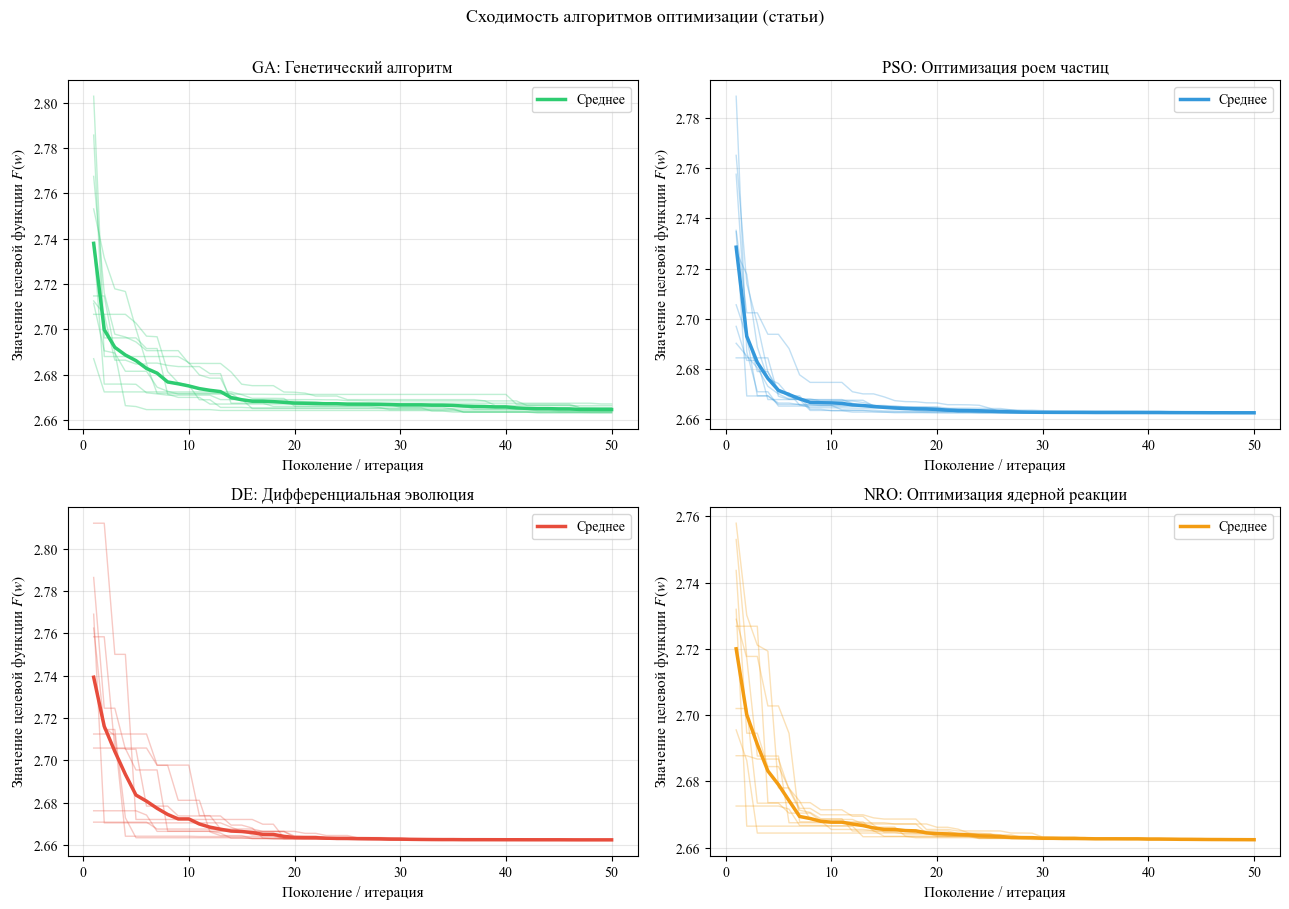

In [126]:
colors = {'GA': '#2ecc71', 'PSO': '#3498db', 'DE': '#e74c3c', 'NRO': '#f39c12'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, res) in zip(axes.flat, results_articles.items()):
    for run in res['runs']:
        ax.plot(range(1, len(run['convergence']) + 1), run['convergence'],
                color=colors[name], alpha=0.3, linewidth=1)
    mean_conv = np.mean([r['convergence'] for r in res['runs']], axis=0)
    ax.plot(range(1, len(mean_conv) + 1), mean_conv,
            color=colors[name], linewidth=2.5, label='Среднее')
    ax.set_xlabel('Поколение / итерация')
    ax.set_ylabel('Значение целевой функции $F(w)$')
    ax.set_title(f'{name}: {res["config"]["name"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Сходимость алгоритмов оптимизации (статьи)', y=1.005)
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


In [127]:
BEST_ALG_ARTICLES = 'PSO'
best_run_A = min(results_articles[BEST_ALG_ARTICLES]['runs'],
                 key=lambda r: r['distance'])
w_opt_A = best_run_A['weights']

weights_table_A = pd.DataFrame({
    'Метрика':         metric_names_articles,
    'Оптимальный_вес': w_opt_A,
    'Процент':         [f'{x*100:.1f}%' for x in w_opt_A],
})
print(f'Оптимальные веса ({BEST_ALG_ARTICLES}, лучший запуск):')
print(weights_table_A.to_string(index=False))
weights_table_A.to_csv(OUT_DIR / 'A_optimal_weights.csv', index=False, encoding='utf-8-sig')

A_opt_articles = A_w_articles(w_opt_A)
expert_flat    = E_articles[off_mask_A]
auto_flat      = A_opt_articles[off_mask_A]
r_combined, p_combined = pearsonr(expert_flat, auto_flat)

single_distances, single_corrs = {}, {}
for name, S in zip(metric_names_articles, S_stack_articles):
    single_distances[name] = float(np.linalg.norm(S - E_articles))
    single_corrs[name], _  = pearsonr(S[off_mask_A], expert_flat)

best_single_name = min(single_distances, key=single_distances.get)
improvement_pct  = ((single_distances[best_single_name] - best_run_A['distance']) /
                     single_distances[best_single_name] * 100)

report_A = pd.DataFrame({
    'Метод':      metric_names_articles + ['Комбинация (PSO)'],
    'Расстояние': [single_distances[n] for n in metric_names_articles] + [best_run_A['distance']],
    'Pearson_r':  [single_corrs[n] for n in metric_names_articles] + [r_combined],
})
print('\nСравнение метрик и комбинации (статьи):')
print(report_A.to_string(index=False))
print(f'\nЛучшая отдельная метрика: {best_single_name} '
      f'(D={single_distances[best_single_name]:.4f})')
print(f'Комбинация: D={best_run_A["distance"]:.4f}')
print(f'Улучшение: {improvement_pct:.2f}%')
print(f'Корреляция Пирсона: r={r_combined:.4f} (p={p_combined:.2e})')
report_A.to_csv(OUT_DIR / 'A_comparison_report.csv', index=False, encoding='utf-8-sig')


Оптимальные веса (PSO, лучший запуск):
 Метрика  Оптимальный_вес Процент
  TF-IDF     2.814054e-01   28.1%
Word2Vec     1.768112e-01   17.7%
    BERT     2.368177e-08    0.0%
     LDA     2.057023e-01   20.6%
    ICAN     3.360811e-01   33.6%

Сравнение метрик и комбинации (статьи):
           Метод  Расстояние  Pearson_r
          TF-IDF    3.936484   0.372702
        Word2Vec    8.910972   0.393585
            BERT    7.739559   0.012475
             LDA    6.241729   0.523931
            ICAN    4.709678   0.314957
Комбинация (PSO)    2.662361   0.598209

Лучшая отдельная метрика: TF-IDF (D=3.9365)
Комбинация: D=2.6624
Улучшение: 32.37%
Корреляция Пирсона: r=0.5982 (p=3.00e-38)


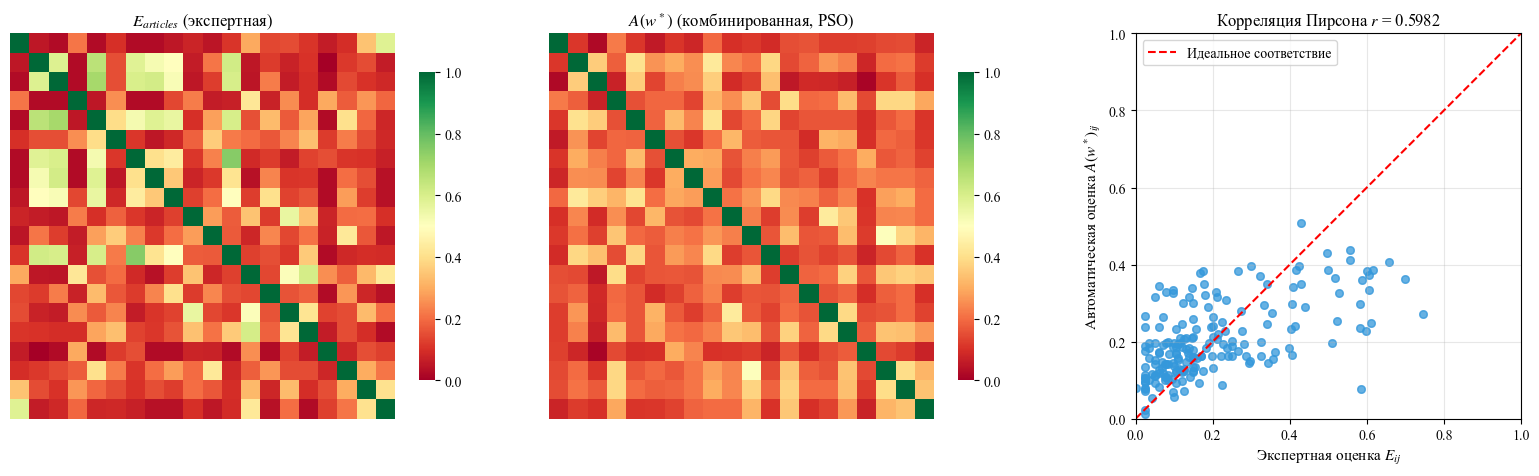

Все артефакты сохранены.


In [128]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_heatmap(E_articles,    '$E_{articles}$ (экспертная)', ax=axes[0])
plot_heatmap(A_opt_articles, f'$A(w^*)$ (комбинированная, {BEST_ALG_ARTICLES})', ax=axes[1])
axes[2].scatter(expert_flat, auto_flat, alpha=0.5, s=30, color='#3498db')
axes[2].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Идеальное соответствие')
axes[2].set_xlabel('Экспертная оценка $E_{ij}$')
axes[2].set_ylabel('Автоматическая оценка $A(w^*)_{ij}$')
axes[2].set_title(f'Корреляция Пирсона $r$ = {r_combined:.4f}')
axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1])
axes[2].legend(); axes[2].grid(True, alpha=0.3); axes[2].set_aspect('equal')
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_best_solution.png', dpi=150, bbox_inches='tight')
plt.show()

np.save(OUT_DIR / 'E_articles.npy', E_articles)
np.save(OUT_DIR / 'A_articles_optimized.npy', A_opt_articles)
pd.DataFrame(E_articles).to_csv(OUT_DIR / 'E_articles.csv', sep=';', index=False)

all_runs_A = []
for name, res in results_articles.items():
    for run in res['runs']:
        all_runs_A.append({
            'Алгоритм': name, 'Запуск': run['run_id'],
            **{f'Вес_{m}': run['weights'][i]
               for i, m in enumerate(metric_names_articles)},
            'Расстояние': run['distance'], 'Время_с': run['time'],
        })
pd.DataFrame(all_runs_A).to_csv(OUT_DIR / 'A_all_runs.csv',
                                  index=False, encoding='utf-8-sig')
print('Все артефакты сохранены.')


## 8. Итоговая сводка

In [136]:
print('=' * 65)
print('ИТОГОВАЯ СВОДКА (СТАТЬИ)')
print('=' * 65)
print(f'\nОбъектов: N = {N_ART}')
print(f'Экспертов: {len(experts_articles)} (агрегация: простое арифметическое среднее)')
print(f'Нормировка: по всей матрице, включая диагональ')
print(f'\nЛучший алгоритм:      {BEST_ALG_ARTICLES}')
print(f'Лучшее расстояние:    {best_run_A["distance"]:.4f}')
print(f'Веса метрик:          ' +
      ', '.join(f'{m}={w:.3f}' for m, w in zip(metric_names_articles, w_opt_A)))
print(f'Корреляция Пирсона:   r = {r_combined:.4f} (p = {p_combined:.2e})')
print(f'Улучшение vs лучшая отдельная метрика: {improvement_pct:.2f}%')
print(f'\nВсе артефакты: {OUT_DIR.resolve()}')


ИТОГОВАЯ СВОДКА (СТАТЬИ)

Объектов: N = 20
Экспертов: 4 (агрегация: простое арифметическое среднее)
Нормировка: по всей матрице, включая диагональ

Лучший алгоритм:      PSO
Лучшее расстояние:    2.6624
Веса метрик:          TF-IDF=0.281, Word2Vec=0.177, BERT=0.000, LDA=0.206, ICAN=0.336
Корреляция Пирсона:   r = 0.5982 (p = 3.00e-38)
Улучшение vs лучшая отдельная метрика: 32.37%

Все артефакты: C:\Users\ksura\anaconda_projects\articles_full_experiment\outputs_articles
